## ANSWERING BUSINESS QUESTIONS

1. What are the dominant transport modes (road, rail, air, water) over time, and how do their freight volumes compare annually and monthly?
- 1.1. How does the distribution of freight volume vary by commodity type over time and mode?
-  1.2 Which origin-destination (OD) pairs or corridors have the highest freight movement, and how have they changed over time?

C:\Users\User\AppData\Local\Temp\ipykernel_3980\2557772454.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=yearly, x='YEAR', y='SHIPWT', palette='Blues_d')


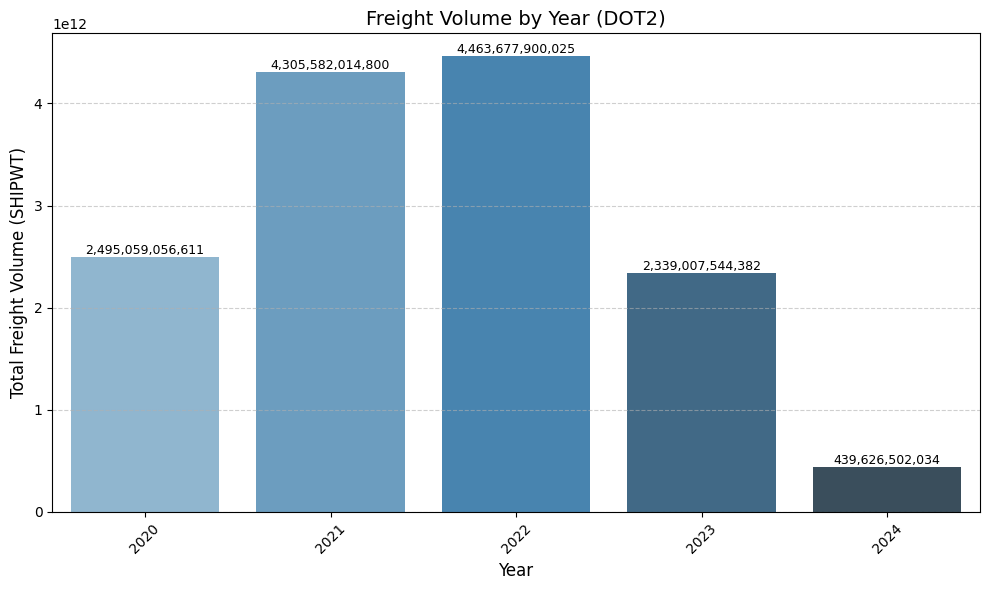

C:\Users\User\AppData\Local\Temp\ipykernel_3980\2557772454.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=yearly, x='YEAR', y='SHIPWT', palette='Blues_d')


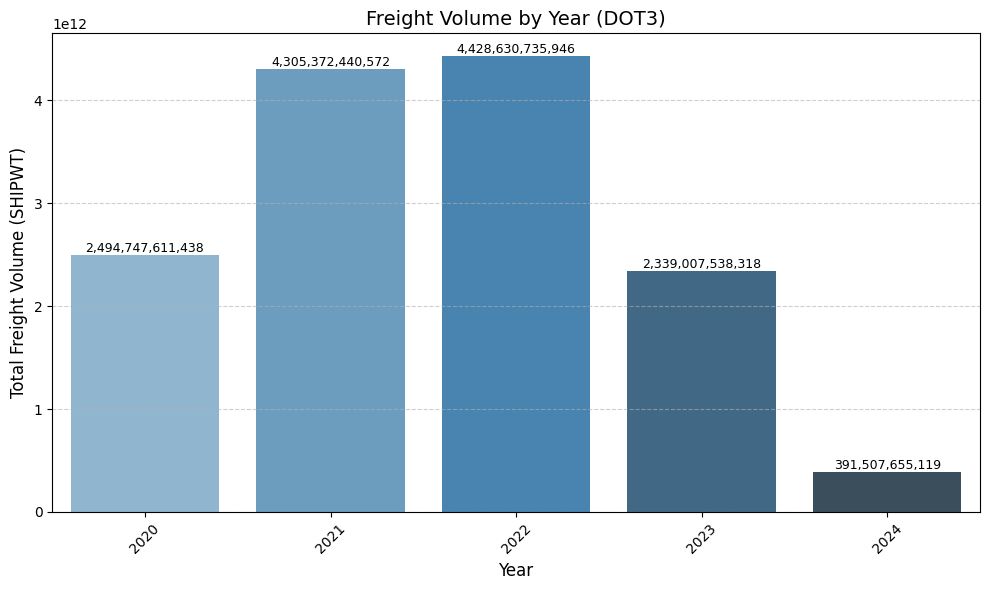

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_freight_volume_by_year(file, title):
    data = pd.read_csv(file, usecols=['YEAR', 'SHIPWT'], low_memory=False)
    data = data.dropna(subset=['YEAR', 'SHIPWT'])
    data['YEAR'] = data['YEAR'].astype(int)

    yearly = data.groupby('YEAR')['SHIPWT'].sum().reset_index()

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(data=yearly, x='YEAR', y='SHIPWT', palette='Blues_d')

    # Add bar labels
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height:,.0f}',  # comma separated, no decimal
                    (p.get_x() + p.get_width() / 2, height),
                    ha='center', va='bottom', fontsize=9, color='black')

    plt.title(f'Freight Volume by Year ({title})', fontsize=14)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Total Freight Volume (SHIPWT)', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Run for all three datasets

plot_freight_volume_by_year('deduped_dot2.csv', 'DOT2')
plot_freight_volume_by_year('deduped_dot3.csv', 'DOT3')


C:\Users\User\AppData\Local\Temp\ipykernel_11724\3427368267.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=monthly, x='MONTH', y='SHIPWT', palette='Greens_d')


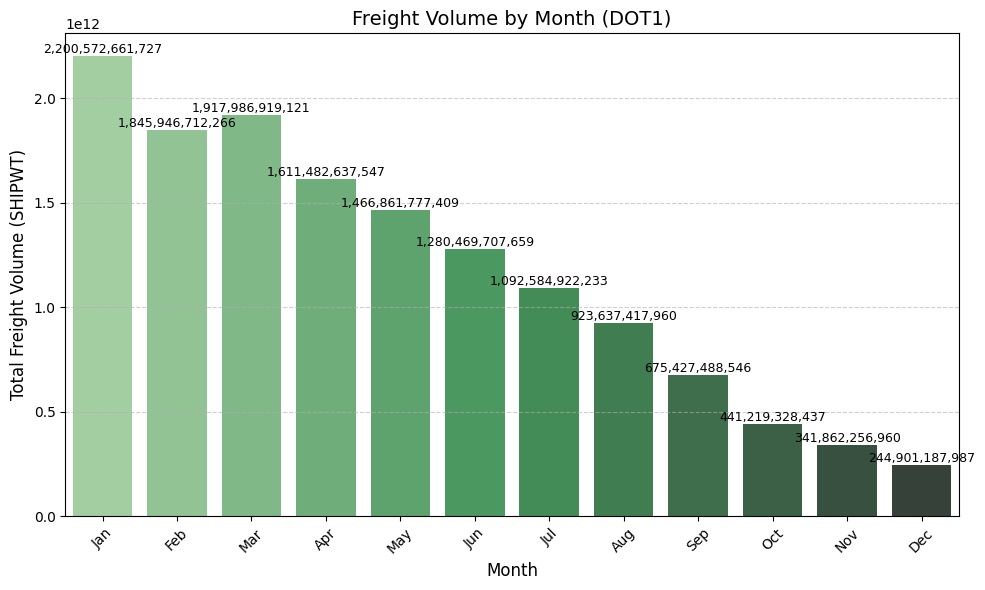

C:\Users\User\AppData\Local\Temp\ipykernel_11724\3427368267.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=monthly, x='MONTH', y='SHIPWT', palette='Greens_d')


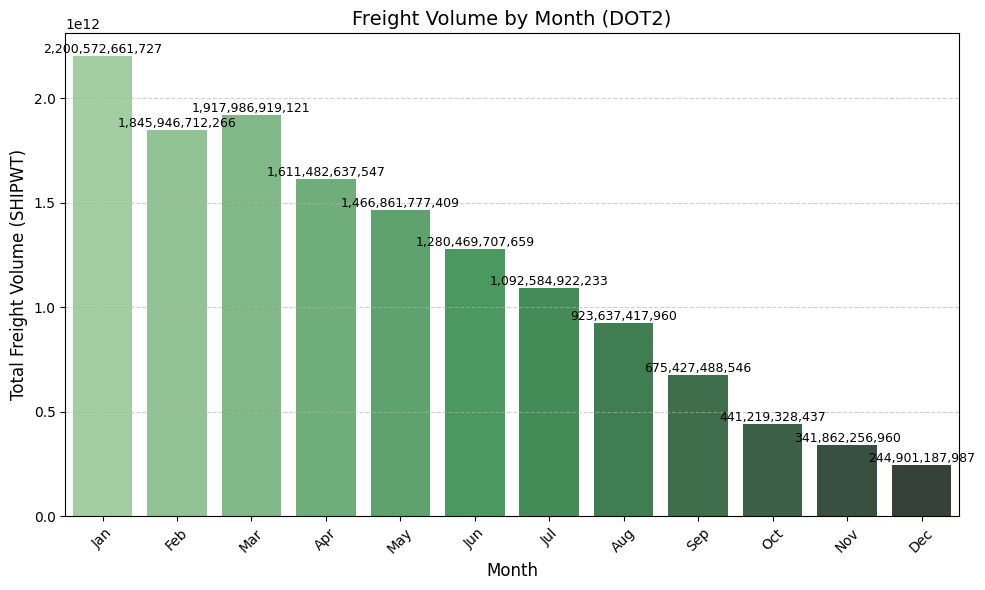

C:\Users\User\AppData\Local\Temp\ipykernel_11724\3427368267.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=monthly, x='MONTH', y='SHIPWT', palette='Greens_d')


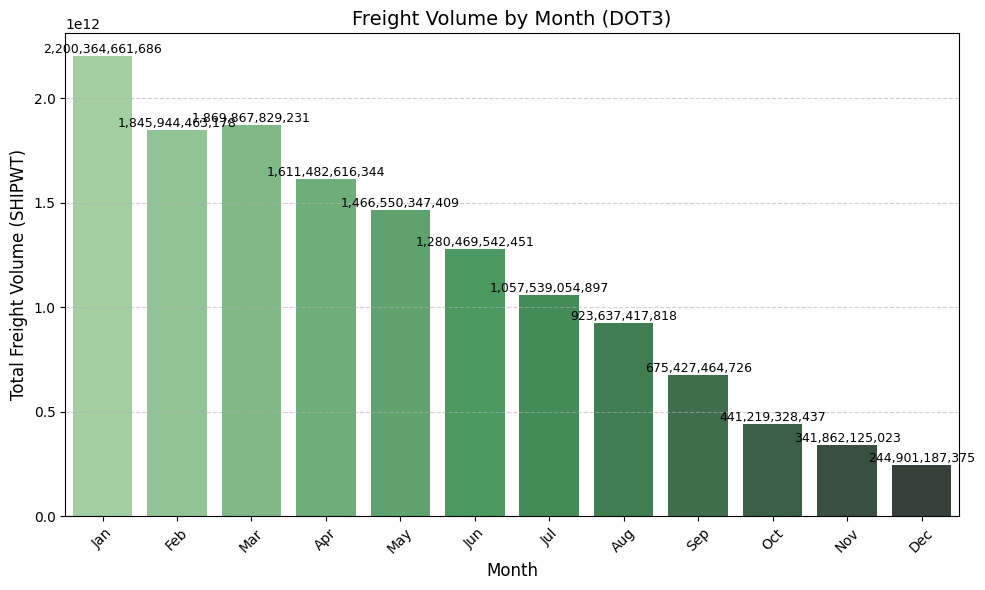

In [1]:
#Monthly
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_freight_volume_by_month(file, title):
    # Load only necessary columns
    data = pd.read_csv(file, usecols=['MONTH', 'SHIPWT'], low_memory=False)
    data = data.dropna(subset=['MONTH', 'SHIPWT'])

    # Ensure proper types
    data['MONTH'] = data['MONTH'].astype(int)
    data['SHIPWT'] = pd.to_numeric(data['SHIPWT'], errors='coerce')
    data = data.dropna()

    # Group and aggregate
    monthly = data.groupby('MONTH')['SHIPWT'].sum().reset_index()

    # Plot
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(data=monthly, x='MONTH', y='SHIPWT', palette='Greens_d')

    # Add data labels on each bar
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height:,.0f}',  # no decimals, commas
                    (p.get_x() + p.get_width() / 2, height),
                    ha='center', va='bottom', fontsize=9, color='black')

    plt.title(f'Freight Volume by Month ({title})', fontsize=14)
    plt.xlabel('Month', fontsize=12)
    plt.ylabel('Total Freight Volume (SHIPWT)', fontsize=12)
    plt.xticks(range(0, 12), 
               ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Apply to all three datasets
plot_freight_volume_by_month('deduped_dot1.csv', 'DOT1')
plot_freight_volume_by_month('deduped_dot2.csv', 'DOT2')
plot_freight_volume_by_month('deduped_dot3.csv', 'DOT3')


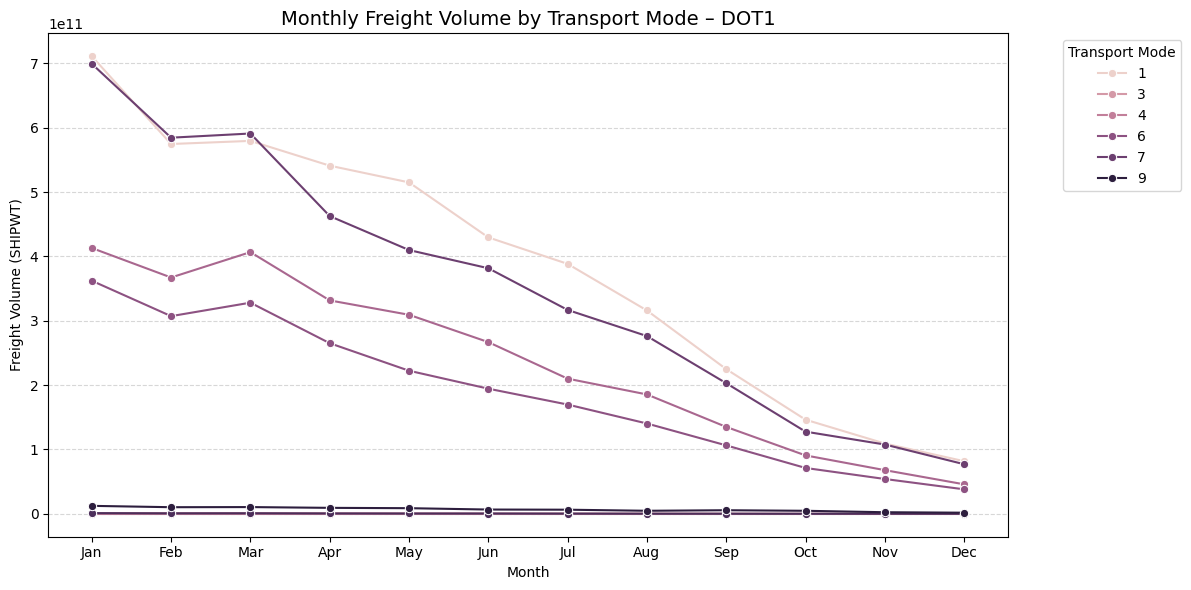

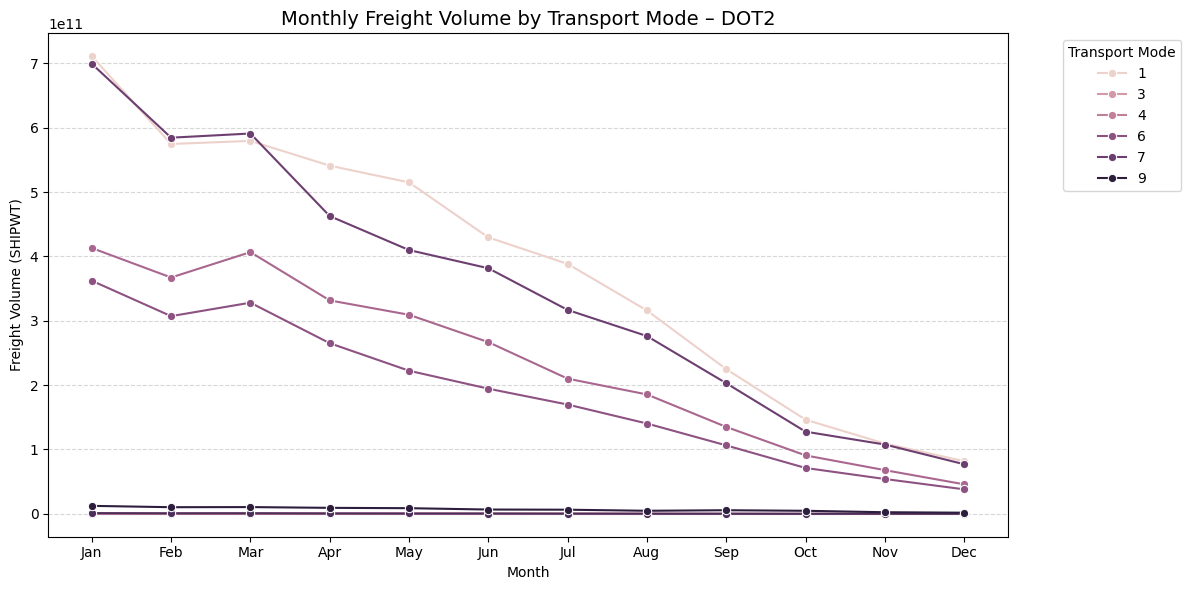

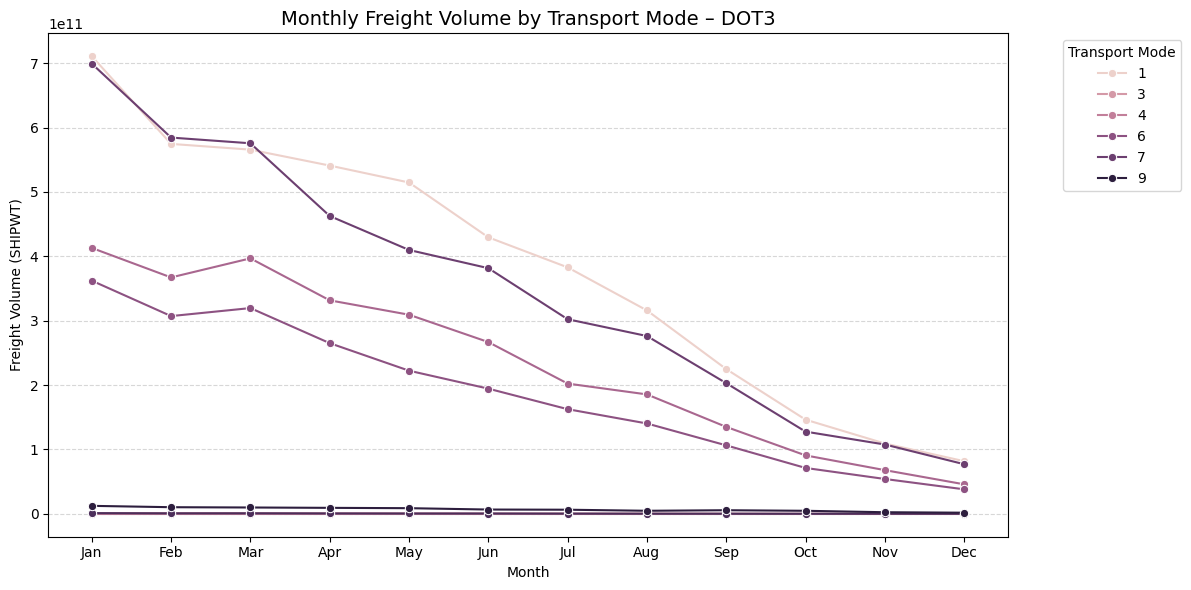

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def lineplot_monthly_by_mode(file, title):
    df = pd.read_csv(file, usecols=['MONTH', 'DISAGMOT', 'SHIPWT'], low_memory=False)
    df.dropna(subset=['MONTH', 'DISAGMOT', 'SHIPWT'], inplace=True)
    df['MONTH'] = df['MONTH'].astype(int)
    df['SHIPWT'] = pd.to_numeric(df['SHIPWT'], errors='coerce')
    df.dropna(inplace=True)

    grouped = df.groupby(['MONTH', 'DISAGMOT'])['SHIPWT'].sum().reset_index()

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=grouped, x='MONTH', y='SHIPWT', hue='DISAGMOT', marker='o')
    plt.title(f'Monthly Freight Volume by Transport Mode – {title}', fontsize=14)
    plt.xlabel('Month')
    plt.ylabel('Freight Volume (SHIPWT)')
    plt.xticks(
        ticks=range(1, 13),
        labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    )
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend(title='Transport Mode', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


lineplot_monthly_by_mode('deduped_dot1.csv', 'DOT1')
lineplot_monthly_by_mode('deduped_dot2.csv', 'DOT2')
lineplot_monthly_by_mode('deduped_dot3.csv', 'DOT3')


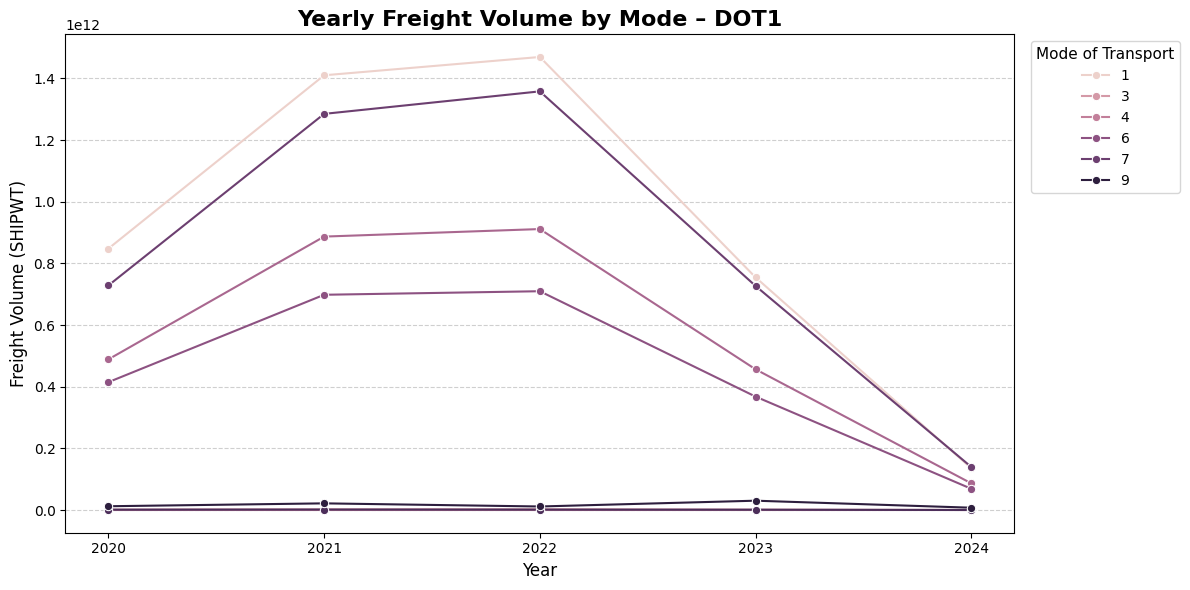

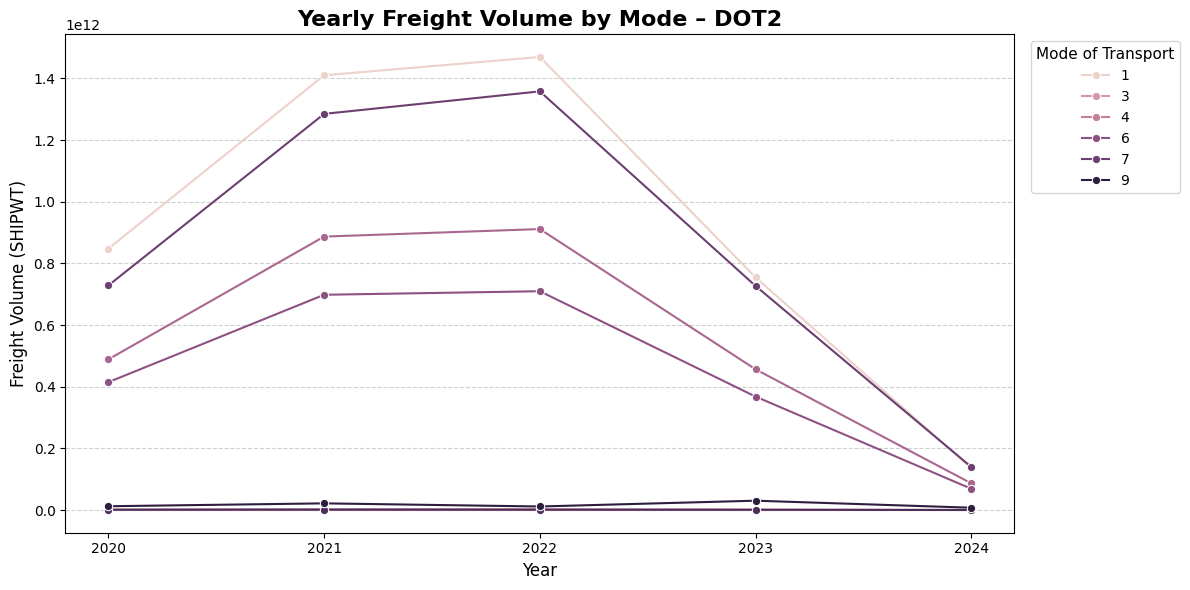

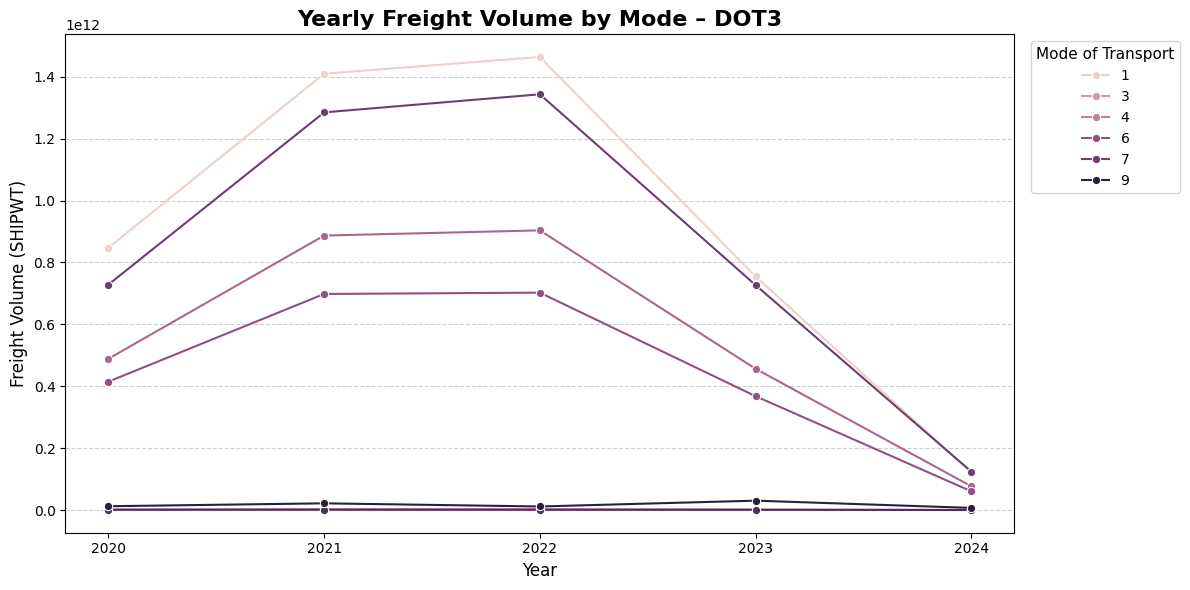

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_yearly_freight_by_mode(file, title):
    df = pd.read_csv(file, usecols=['YEAR', 'DISAGMOT', 'SHIPWT'], low_memory=False)
    df.dropna(subset=['YEAR', 'DISAGMOT', 'SHIPWT'], inplace=True)
    
    # Convert data types
    df['YEAR'] = pd.to_numeric(df['YEAR'], errors='coerce').astype('Int64')
    df['SHIPWT'] = pd.to_numeric(df['SHIPWT'], errors='coerce')
    df.dropna(inplace=True)

    # Group and sort
    grouped = df.groupby(['YEAR', 'DISAGMOT'])['SHIPWT'].sum().reset_index()
    grouped = grouped.sort_values(by='YEAR')

    # Set integer years as ticks
    unique_years = sorted(grouped['YEAR'].dropna().unique())

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=grouped, x='YEAR', y='SHIPWT', hue='DISAGMOT', marker='o')

    plt.title(f'Yearly Freight Volume by Mode – {title}', fontsize=16, fontweight='bold')
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Freight Volume (SHIPWT)', fontsize=12)
    plt.xticks(ticks=unique_years, labels=[str(int(yr)) for yr in unique_years], fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.legend(title='Mode of Transport', title_fontsize=11, fontsize=10, bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

  
plot_yearly_freight_by_mode('deduped_dot1.csv', 'DOT1')
plot_yearly_freight_by_mode('deduped_dot2.csv', 'DOT2')
plot_yearly_freight_by_mode('deduped_dot3.csv', 'DOT3')


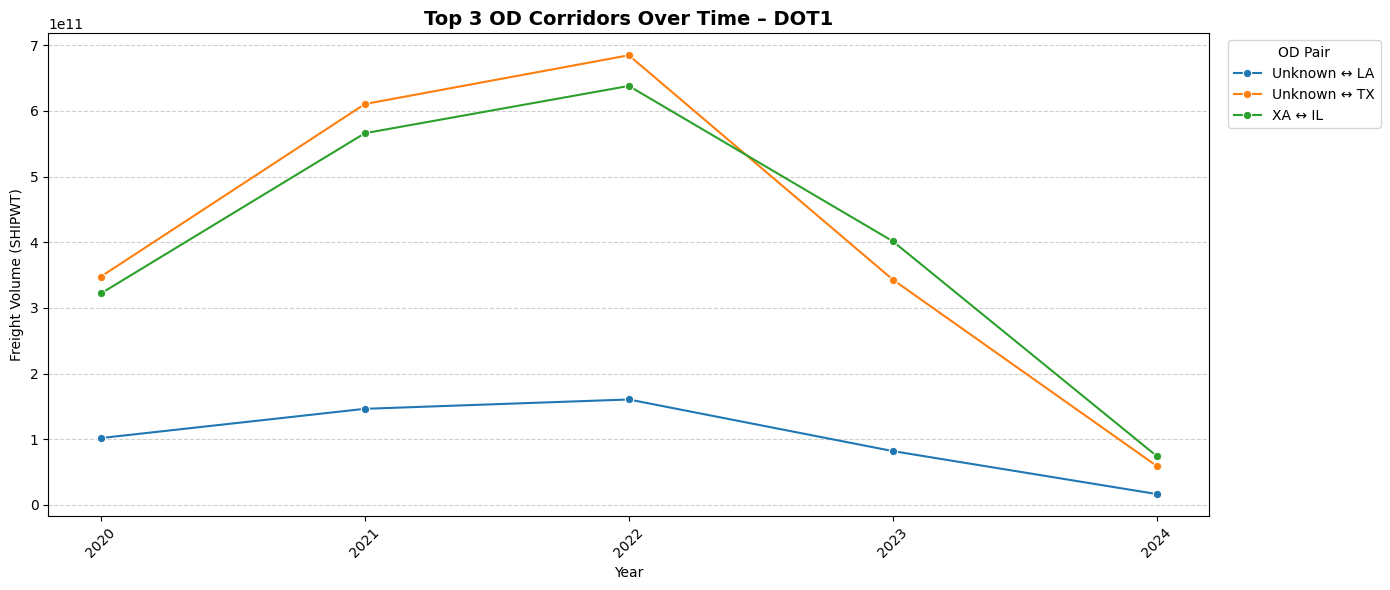

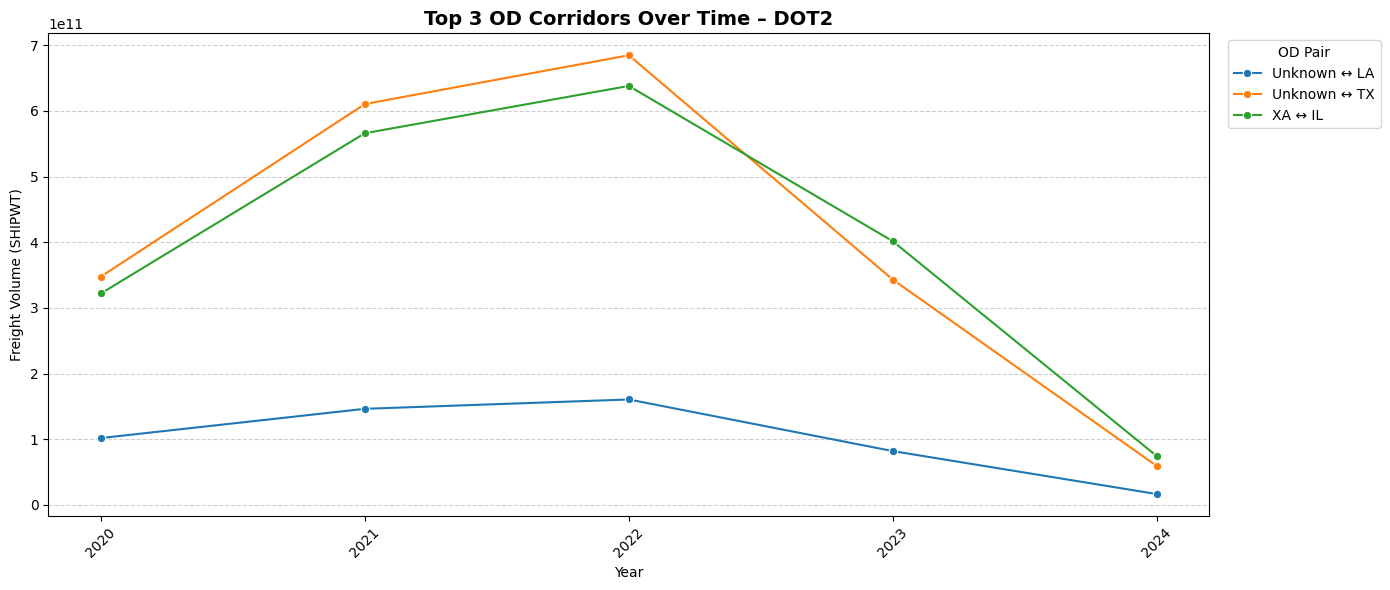

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def top_od_corridors_by_year(file, title, top_n=3, chunk_size=100_000):
    cols = ['CANPROV', 'USASTATE', 'YEAR', 'SHIPWT']
    od_data = pd.DataFrame()

    for chunk in pd.read_csv(file, usecols=cols, chunksize=chunk_size, low_memory=False):
        chunk.dropna(subset=['CANPROV', 'USASTATE', 'YEAR', 'SHIPWT'], inplace=True)
        chunk['YEAR'] = pd.to_numeric(chunk['YEAR'], errors='coerce').astype('Int64')
        chunk['SHIPWT'] = pd.to_numeric(chunk['SHIPWT'], errors='coerce')
        chunk.dropna(inplace=True)

        chunk['OD_PAIR'] = chunk['CANPROV'].astype(str) + ' ↔ ' + chunk['USASTATE'].astype(str)
        g = chunk.groupby(['YEAR', 'OD_PAIR'])['SHIPWT'].sum().reset_index()
        od_data = pd.concat([od_data, g], ignore_index=True)

    final = od_data.groupby(['YEAR', 'OD_PAIR'])['SHIPWT'].sum().reset_index()

    # Ensure YEAR is integer (not Int64) and sort
    final['YEAR'] = final['YEAR'].astype(int)
    final.sort_values('YEAR', inplace=True)

    # Get top N OD pairs by total weight
    top_pairs = final.groupby('OD_PAIR')['SHIPWT'].sum().nlargest(top_n).index
    top_final = final[final['OD_PAIR'].isin(top_pairs)]

    plt.figure(figsize=(14, 6))
    sns.lineplot(data=top_final, x='YEAR', y='SHIPWT', hue='OD_PAIR', marker='o')
    plt.title(f'Top {top_n} OD Corridors Over Time – {title}', fontsize=14, fontweight='bold')
    plt.xlabel('Year')
    plt.ylabel('Freight Volume (SHIPWT)')
    
    # Show only unique sorted years as integers
    years = sorted(top_final['YEAR'].unique())
    plt.xticks(ticks=years, labels=[str(y) for y in years], rotation=45)

    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.legend(title='OD Pair', bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


top_od_corridors_by_year('deduped_dot1.csv', 'DOT1')
top_od_corridors_by_year('deduped_dot2.csv', 'DOT2')


2. Which commodities contribute the most to freight value and volume across different modes and trade partners (US, Canada, Mexico)?

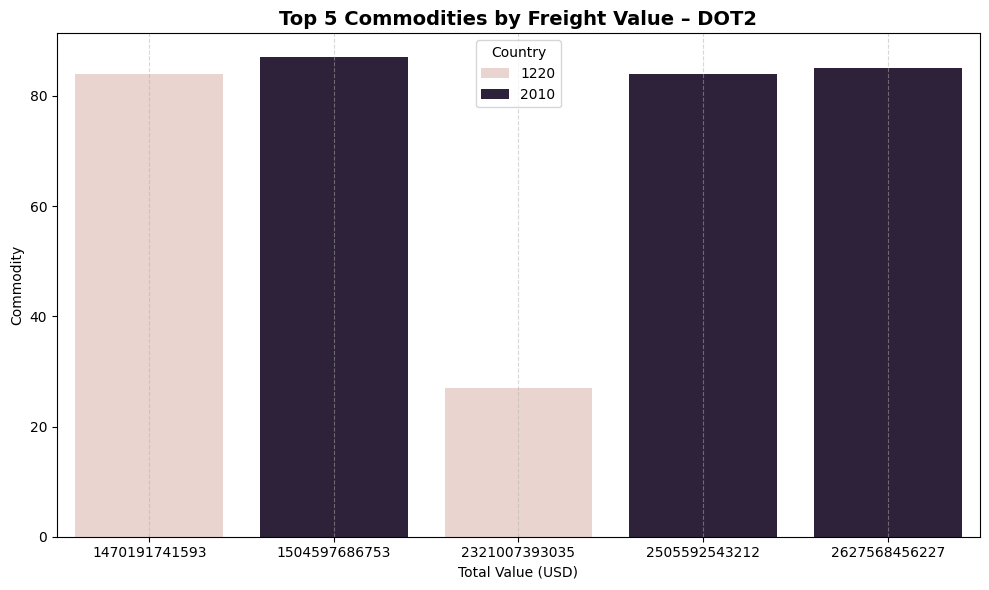

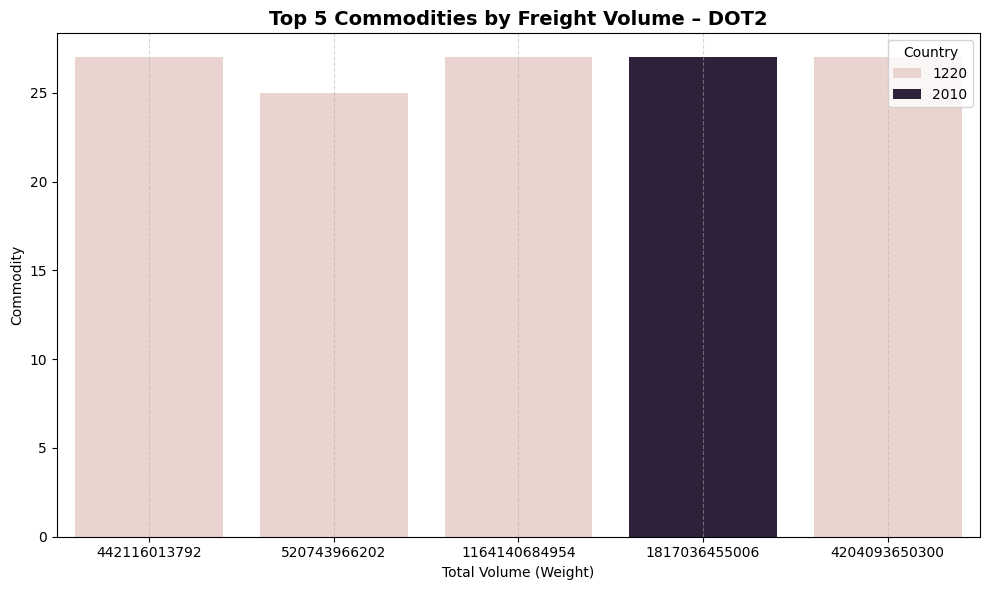

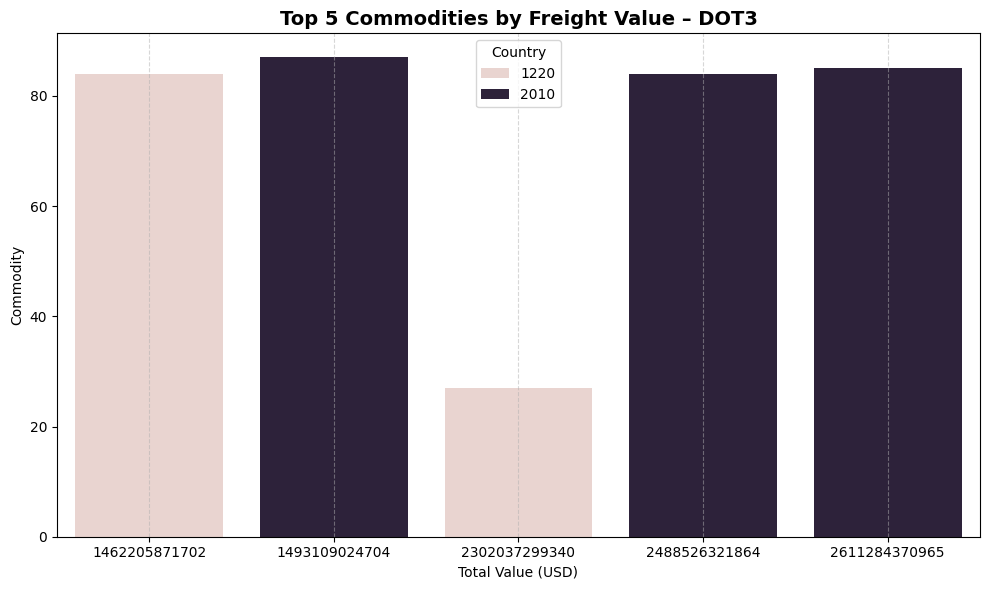

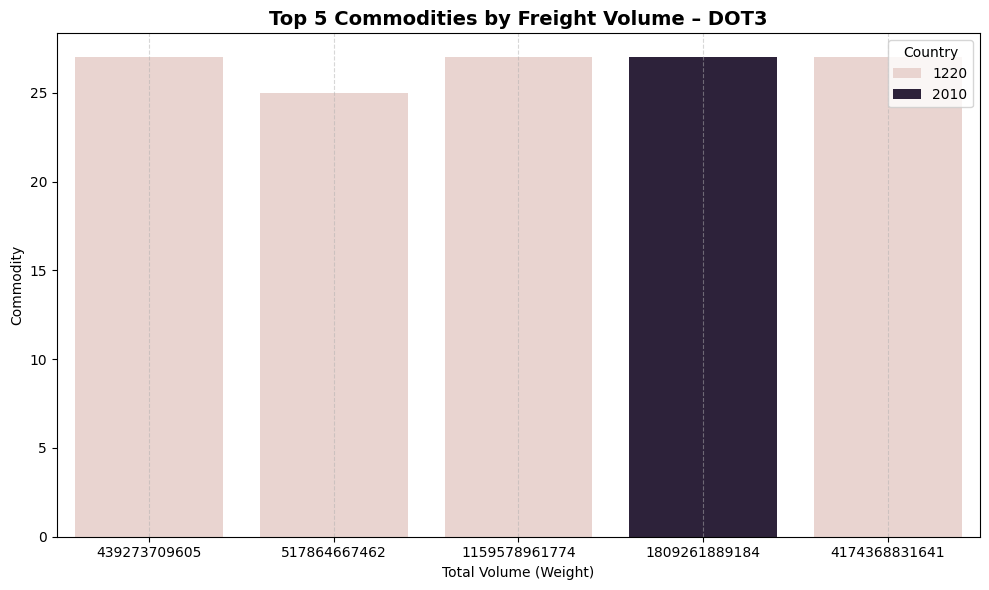

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_and_plot_top_commodities(file, title, chunk_size=100_000):
    usecols = ['COMMODITY2', 'DISAGMOT', 'COUNTRY', 'VALUE', 'SHIPWT']
    df = pd.DataFrame()

    for chunk in pd.read_csv(file, usecols=usecols, chunksize=chunk_size, low_memory=False):
        chunk.dropna(subset=['COMMODITY2', 'VALUE', 'SHIPWT', 'COUNTRY', 'DISAGMOT'], inplace=True)
        chunk['VALUE'] = pd.to_numeric(chunk['VALUE'], errors='coerce')
        chunk['SHIPWT'] = pd.to_numeric(chunk['SHIPWT'], errors='coerce')
        df = pd.concat([df, chunk], ignore_index=True)

    summary = df.groupby(['COMMODITY2', 'DISAGMOT', 'COUNTRY']).agg(
        Total_Value=('VALUE', 'sum'),
        Total_Volume=('SHIPWT', 'sum')
    ).reset_index()

    # Top 10 by Value
    top_val = (
        summary.nlargest(5, 'Total_Value')
        .sort_values('Total_Value', ascending=True)
    )

    # Top 10 by Volume
    top_vol = (
        summary.nlargest(5, 'Total_Volume')
        .sort_values('Total_Volume', ascending=True)
    )

    # Plot Top by Value
    plt.figure(figsize=(10, 6))
    sns.barplot(data=top_val, x='Total_Value', y='COMMODITY2', hue='COUNTRY')
    plt.title(f'Top 5 Commodities by Freight Value – {title}', fontsize=14, fontweight='bold')
    plt.xlabel('Total Value (USD)')
    plt.ylabel('Commodity')
    plt.legend(title='Country')
    plt.tight_layout()
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.show()

    # Plot Top by Volume
    plt.figure(figsize=(10, 6))
    sns.barplot(data=top_vol, x='Total_Volume', y='COMMODITY2', hue='COUNTRY')
    plt.title(f'Top 5 Commodities by Freight Volume – {title}', fontsize=14, fontweight='bold')
    plt.xlabel('Total Volume (Weight)')
    plt.ylabel('Commodity')
    plt.legend(title='Country')
    plt.tight_layout()
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.show()

# Run for each file
analyze_and_plot_top_commodities('deduped_dot2.csv', 'DOT2')
analyze_and_plot_top_commodities('deduped_dot3.csv', 'DOT3')


3. Which origin-destination (OD) corridors handle the largest freight volumes, and how have these patterns changed over time?

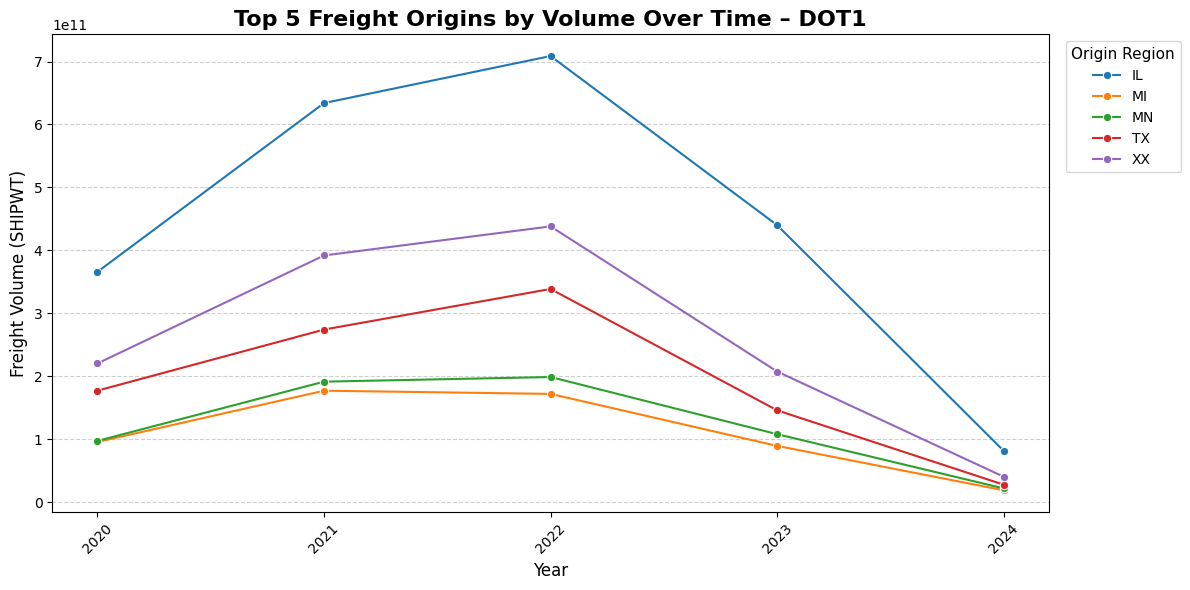

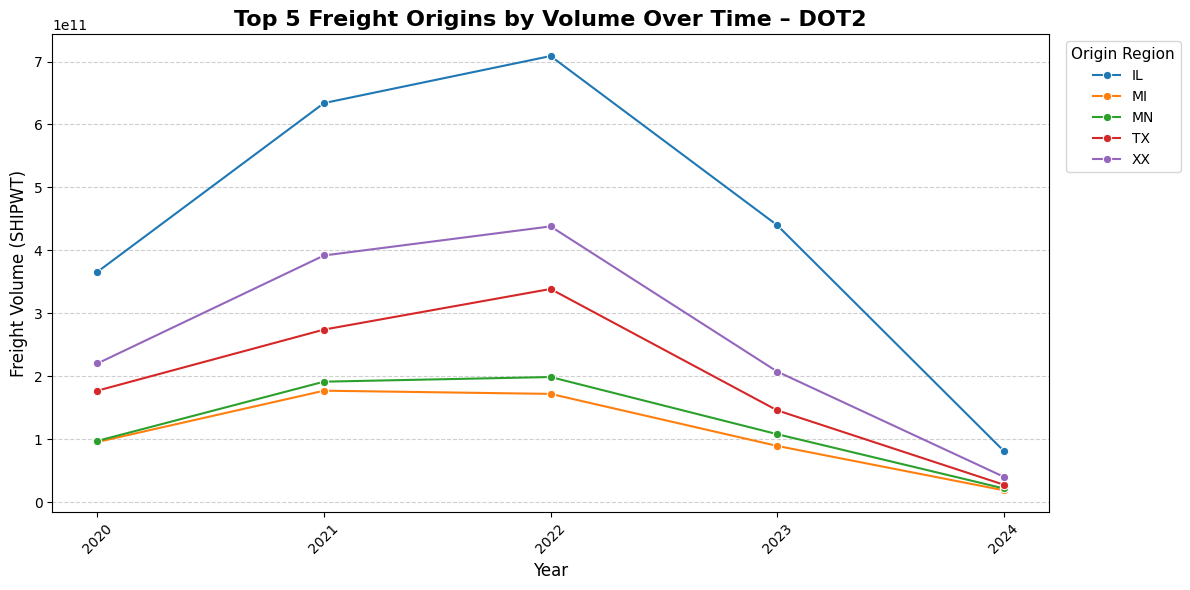

In [8]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_top_od_corridors(file, title, top_n=5, chunk_size=100_000):
    cols = ['USASTATE', 'CANPROV', 'MEXSTATE', 'COUNTRY', 'YEAR', 'SHIPWT']
    od_data = pd.DataFrame()

    for chunk in pd.read_csv(file, usecols=cols, chunksize=chunk_size, low_memory=False):
        chunk.dropna(subset=['COUNTRY', 'YEAR', 'SHIPWT'], inplace=True)
        chunk['YEAR'] = chunk['YEAR'].astype(int)
        chunk['SHIPWT'] = pd.to_numeric(chunk['SHIPWT'], errors='coerce')
        chunk.dropna(subset=['SHIPWT'], inplace=True)

        chunk['ORIGIN'] = chunk.apply(
            lambda row: row['USASTATE'] if row['COUNTRY'] == 1220 and pd.notna(row['USASTATE'])
            else (row['CANPROV'] if row['COUNTRY'] == 124 and pd.notna(row['CANPROV'])
                  else row['MEXSTATE']),
            axis=1
        )
        chunk['ORIGIN'] = chunk['ORIGIN'].fillna('Unknown')
        chunk = chunk[chunk['ORIGIN'] != 'Unknown']


        od_group = (
            chunk.groupby(['ORIGIN', 'YEAR'])['SHIPWT']
            .sum()
            .reset_index()
        )
        od_data = pd.concat([od_data, od_group], ignore_index=True)

    # Aggregate across all chunks
    od_data = (
        od_data.groupby(['ORIGIN', 'YEAR'])['SHIPWT']
        .sum()
        .reset_index()
    )

    # Get top N origins by total volume
    top_origins = (
        od_data.groupby('ORIGIN')['SHIPWT']
        .sum()
        .nlargest(top_n)
        .index
    )
    top_od_data = od_data[od_data['ORIGIN'].isin(top_origins)]

    # Plot
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=top_od_data, x='YEAR', y='SHIPWT', hue='ORIGIN', marker='o')
    plt.title(f'Top {top_n} Freight Origins by Volume Over Time – {title}', fontsize=16, fontweight='bold')
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Freight Volume (SHIPWT)', fontsize=12)

    # Set x-axis ticks to unique integer years only
    unique_years = sorted(top_od_data['YEAR'].unique())
    plt.xticks(unique_years, fontsize=10, rotation=45)

    plt.yticks(fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.legend(title='Origin Region', title_fontsize=11, fontsize=10, bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
   
analyze_top_od_corridors('deduped_dot1.csv', 'DOT1')
analyze_top_od_corridors('deduped_dot2.csv', 'DOT2')




4. Are there inefficiencies or cost anomalies in freight transport, such as unusually high freight charges relative to shipment weight or value?

DOT1 — Anomalies Detected: 922359 rows out of 4102985


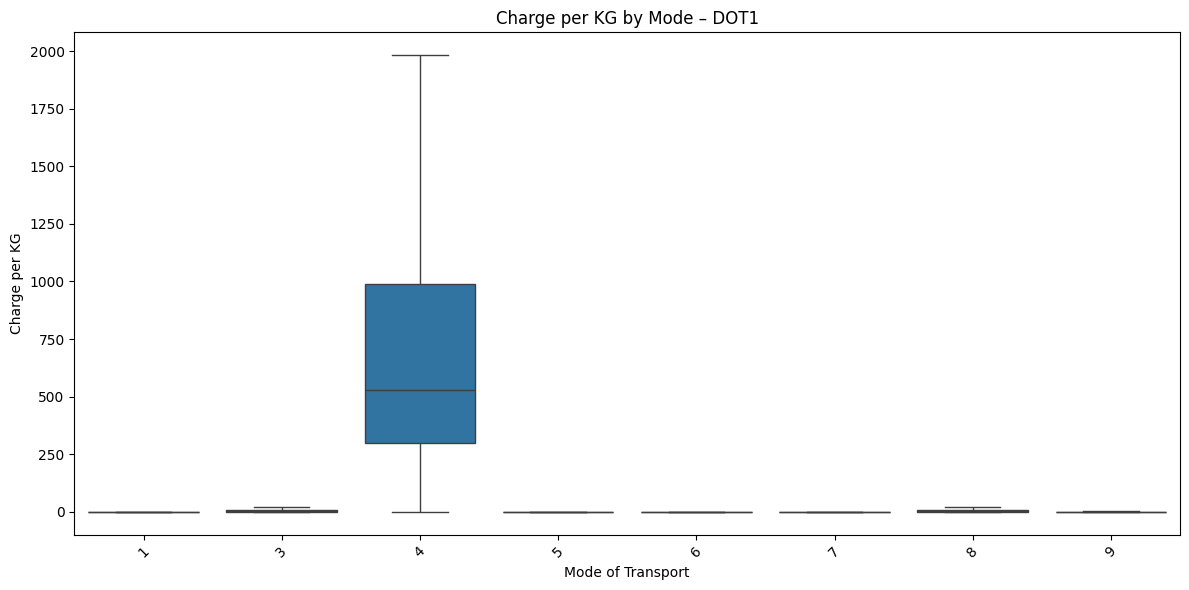

DOT2 — Anomalies Detected: 2100481 rows out of 9014887


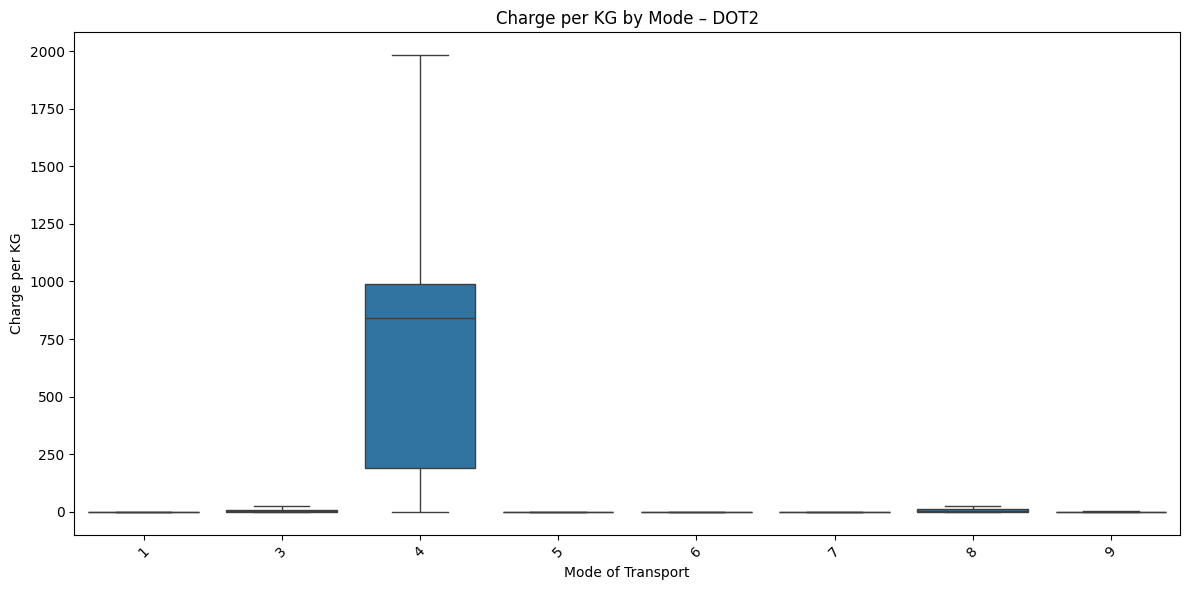

DOT3 — Anomalies Detected: 637354 rows out of 2780610


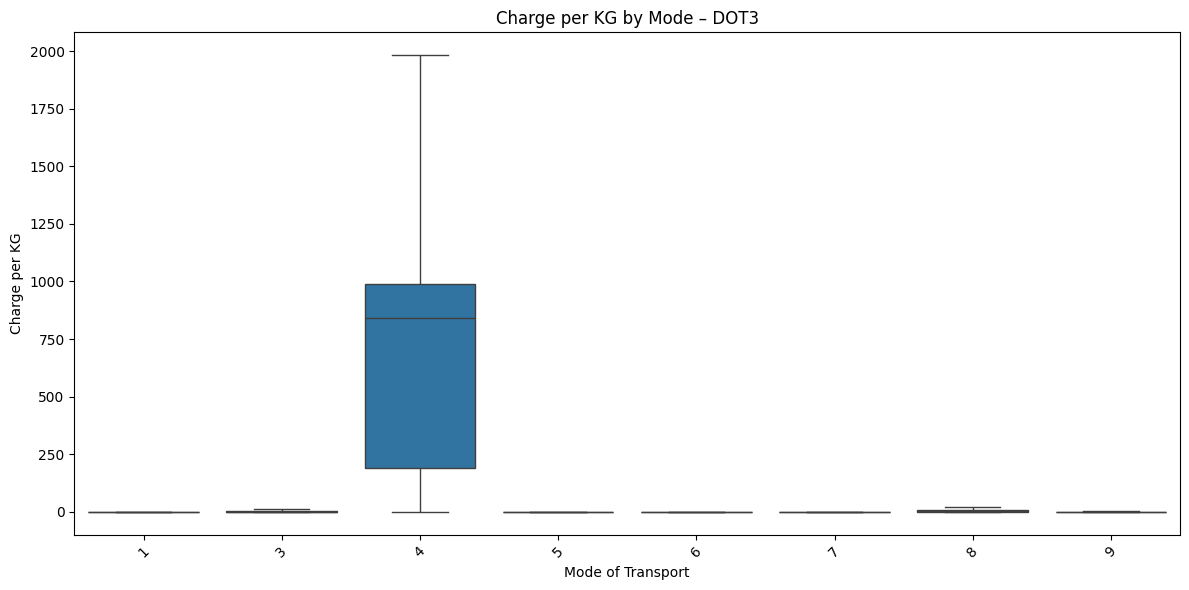

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def detect_cost_anomalies(file, title, chunk_size=100000):
    cols = ['FREIGHT_CHARGES', 'SHIPWT', 'VALUE', 'YEAR', 'DISAGMOT']
    data = []

    for chunk in pd.read_csv(file, usecols=cols, chunksize=chunk_size, low_memory=False):
        chunk = chunk.dropna(subset=['FREIGHT_CHARGES', 'SHIPWT', 'VALUE', 'YEAR'])
        chunk = chunk[(chunk['SHIPWT'] > 0) & (chunk['VALUE'] > 0)]

        # Calculate charge ratios
        chunk['Charge_per_kg'] = chunk['FREIGHT_CHARGES'] / chunk['SHIPWT']
        chunk['Charge_per_dollar'] = chunk['FREIGHT_CHARGES'] / chunk['VALUE']
        chunk['YEAR'] = chunk['YEAR'].astype(int)

        data.append(chunk)

    df = pd.concat(data)

    # Use IQR to detect anomalies in Charge_per_kg
    def flag_anomalies(series):
        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)
        IQR = Q3 - Q1
        return (series < (Q1 - 1.5 * IQR)) | (series > (Q3 + 1.5 * IQR))

    df['Charge_per_kg_anomaly'] = flag_anomalies(df['Charge_per_kg'])
    df['Charge_per_dollar_anomaly'] = flag_anomalies(df['Charge_per_dollar'])

    # Summary
    anomalies = df[df['Charge_per_kg_anomaly'] | df['Charge_per_dollar_anomaly']]
    print(f"{title} — Anomalies Detected: {len(anomalies)} rows out of {len(df)}")

    # Plotting
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x='DISAGMOT', y='Charge_per_kg', showfliers=False)
    plt.title(f'Charge per KG by Mode – {title}')
    plt.ylabel('Charge per KG')
    plt.xlabel('Mode of Transport')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return anomalies[['YEAR', 'DISAGMOT', 'FREIGHT_CHARGES', 'SHIPWT', 'VALUE', 'Charge_per_kg', 'Charge_per_dollar']].sort_values(by='Charge_per_kg', ascending=False).head(20)
 
df_dot1_anomalies = detect_cost_anomalies('deduped_dot1.csv', 'DOT1')
df_dot2_anomalies = detect_cost_anomalies('deduped_dot2.csv', 'DOT2')
df_dot3_anomalies = detect_cost_anomalies('deduped_dot3.csv', 'DOT3')



5. Which commodities have seen the most growth or decline in freight volume in the past 5 years?

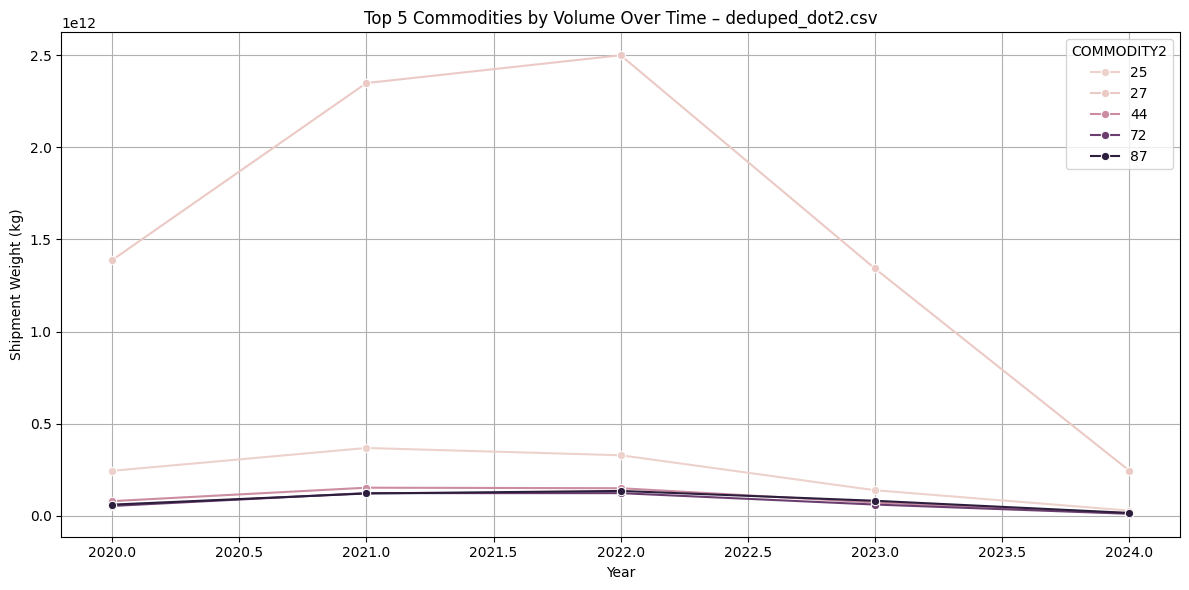

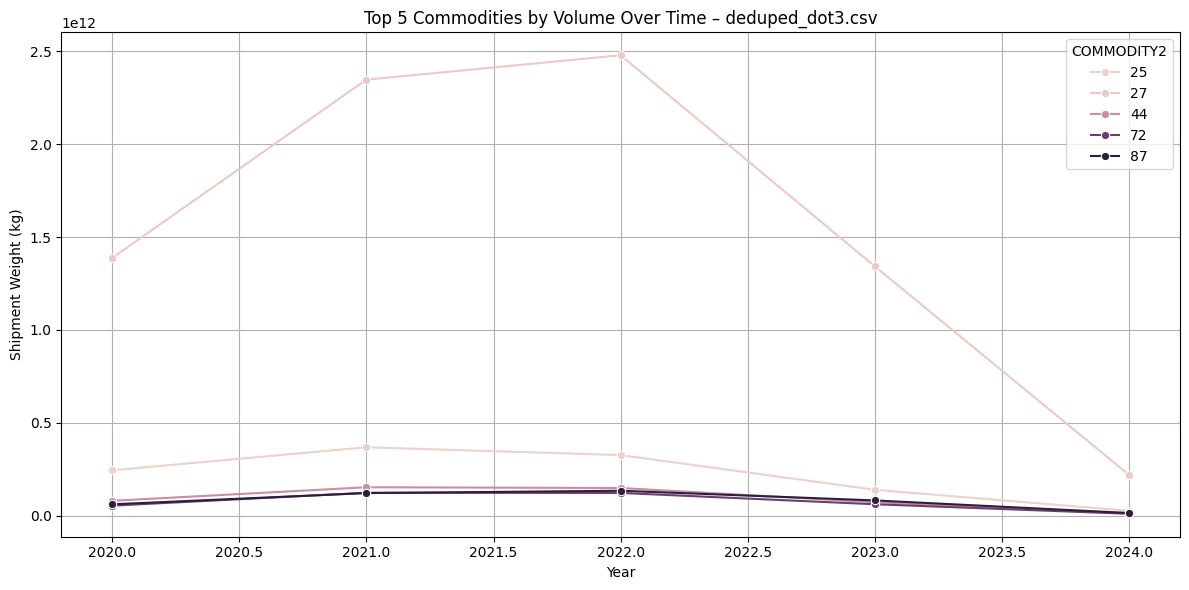

In [13]:
def top_commodity_trends(file):
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    df = pd.read_csv(file, usecols=['YEAR', 'COMMODITY2', 'SHIPWT'])
    df.dropna(subset=['YEAR', 'COMMODITY2', 'SHIPWT'], inplace=True)
    df['YEAR'] = df['YEAR'].astype(int)

    totals = df.groupby('COMMODITY2')['SHIPWT'].sum().sort_values(ascending=False)
    top5 = totals.head(5).index.tolist()

    top_df = df[df['COMMODITY2'].isin(top5)]
    trend = top_df.groupby(['YEAR', 'COMMODITY2'])['SHIPWT'].sum().reset_index()

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=trend, x='YEAR', y='SHIPWT', hue='COMMODITY2', marker='o')
    plt.title(f'Top 5 Commodities by Volume Over Time – {file}')
    plt.xlabel('Year')
    plt.ylabel('Shipment Weight (kg)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
top_commodity_trends('deduped_dot2.csv')
top_commodity_trends('deduped_dot3.csv')

# Business Analysis Summary of Transborder Freight Data

1. Top Commodities by Value and Volume
Key observations include:

- Common high-value commodities include electronics, vehicles, and machinery.

- Heavier commodities like oil, minerals, and construction materials dominate the volume metrics.

  Insight: Value-heavy commodities may require tighter security and temperature-controlled logistics, while volume-heavy ones may stress infrastructure more.

  Recommendation: Optimize high-volume corridors for better infrastructure investment and tailor logistics services for high-value freight (e.g., insurance, faster routes).


2. Freight Movement by Mode (DISAGMOT)
Both yearly and monthly breakdowns of freight by transport mode showed clear usage patterns:

- Truck transport consistently dominated, followed by rail and pipeline in terms of volume.

- Seasonal fluctuations (peaks in summer) were evident in monthly plots.

   Insight: Overreliance on trucks may cause highway congestion and emissions.

   Recommendation: Promote rail and multimodal logistics through incentives to reduce environmental impact and road congestion.


3. Top Origin-Destination (OD) Corridors
The analysis identified the top OD pairs by total shipment weight. These corridors are the lifelines of trade between the US, Canada, and Mexico.

   Insight: A few corridors handle the bulk of freight 

   Recommendation: Invest in alternate routes and backup infrastructure to reduce the risk of disruptions on primary corridors.


4. Freight Cost Anomalies
 We calculated freight charges per kg and per dollar value to find anomalies.

   Some entries had abnormally high cost per kg or low value per ton.

   Insight: These anomalies might signal inefficiencies, fraud, or data errors.

   Recommendation: Audit such records and work with logistics partners to streamline cost structures, especially where ratios seem unreasonable.
   

5. Commodity Trends Over Time (2020–2024)
   Insight: Commodities like "27 – Mineral Fuels" and "25 – Salt/Sulfur" showed massive volume peaks in 2021–2022 but declined sharply by 2024.

   "87 – Vehicles" and "72 – Iron and Steel" were more stable.

    These changes likely correlate with energy market volatility and post-pandemic industrial recovery.

    Recommendation:
    Monitor energy-related commodities closely and hedge against volume shocks. Ensure flexibility in mode choice for volatile segments.
